# Explainable and Interpretable Anomaly Detection in Telecom Networks

This notebook focuses on engineering interpretability. Our aim is to convert the opaque outputs of black-box models into clear, understandable insights that engineers can use. This clarity is essential for root-cause analysis, network performance optimization, and effective troubleshooting. We will use several key techniques, including SHAP (Shapley Additive Explanations), LIME (Local Interpretable Model-agnostic Explanations), and visualization tools like Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE) plots. These methods will help us identify the most significant variables and the interactions between various features.

**Target audience:** Telecom engineers, network performance analysts, PhD students in computer networks, and data scientists working on critical infrastructure monitoring.

## Learning objectives

By the end of this notebook, participants will be able to:

1. **Discretize continuous KPIs** into interpretable quality categories using binning techniques.
2. **Build interpretable normality models** using decision trees to characterize the normal network behavior.
3. **Identify anomaly candidates** by analyzing model prediction errors and misestimation patterns.
4. **Train robust regression models** (XGBoost, Gradient Boosting, AdaBoost) for building normality models.
5. **Compare feature importance** across multiple ensemble methods.
6. **Interpret model behavior globally** using SHAP summary plots and feature contribution analysis.
7. **Analyze feature interactions** through SHAP dependence plots and correlation heatmaps.
8. **Explain individual predictions locally** using LIME.
9. **Apply partial dependence techniques** (PDP and ICE) to understand marginal feature effects.

## Expected outcomes

- Ability to implement interpretability tools
- Skills to interpret complex ML models in telecom contexts
- Framework for converting model outputs into engineering recommendations
- Understanding of when and how to apply different explanation techniques

## Notebook structure

1. **Environment Setup**: Import required libraries and configure the analysis environment.
2. **Load the Clean Dataset**: Prepare the telecom drive-test data for analysis.
3. **Build Interpretable Normality Models**: Use decision trees to model expected network behavior patterns.
4. **Explain Model Predictions**: Apply multiple interpretability techniques including:
   - Global feature importance analysis across ensemble methods
   - SHAP-based explanations (summary plots, dependence plots, correlations)
   - Partial dependence and individual conditional expectation plots
   - Local explanations with LIME for individual anomalies

## Key techniques covered

- **Decision Trees** for interpretable classification
- **Ensemble Methods** (XGBoost, Gradient Boosting, AdaBoost) for robust regression
- **SHAP** for additive feature attribution
- **LIME** for local surrogate explanations
- **PDP/ICE** for marginal effect analysis
- **Correlation Analysis** for feature relationship assessment

This notebook serves as both a tutorial and a reference implementation for interpretable machine learning.

In [111]:
# !git clone https://github.com/JuanMarcosRamirez/xmlad.git
# !pip install lime

# import os
# os.chdir('/content/xmlad')

# import sys
# sys.path.append('/content/xmlad')

## 1. Environment Setup

In [112]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV  # NEW
from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from xgboost import XGBRegressor

from srcs.anmdet import (
    detect_outliers_mad,
)
from srcs.models import build_decision_tree
from srcs.plot_functions import plot_pruning

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="talk")

## 2. Load the Clean Dataset

In [113]:
# ------------------------------------------------------------
# Bootcamp group selection
# Change only this line: 1 for Group 1, 2 for Group 2
# ------------------------------------------------------------
GROUP_ID = 1  # Change to 2 for Group 2

GROUP_DATASETS = {
    1: "operator1_DL_cleaned",
    2: "operator2_DL_cleaned",
}

if GROUP_ID not in GROUP_DATASETS:
    raise ValueError(f"Invalid GROUP_ID={GROUP_ID}. Choose 1 or 2.")

DATA_FILE = GROUP_DATASETS[GROUP_ID]
DATA_PATH = Path("datasets") / f"{DATA_FILE}.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place the CSV in the expected folder or update DATA_PATH before running this notebook."
    )

data = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    sep=",",
    decimal=".",
    low_memory=False,
)

print(f"Cleaned dataset shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns")
display(data.head())

Cleaned dataset shape: 1,001 rows x 120 columns


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.b2a,throughput.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,fin.pkts.sent.a2b,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.50,abs.downlinkdelay.75,abs.downlinkdelay.max,abs.uplinkdelay.25,abs.uplinkdelay.50,abs.uplinkdelay.avg,abs.uplinkdelay.75,abs.uplinkdelay.max,abs.downlinkdeltadelay.25,abs.uplinkdeltadelay.avg,abs.rtt.min,abs.rtt.25,abs.rtt.50,abs.rtt.avg,abs.rtt.75,abs.rtt.max,abs.cwin.min,abs.cwin.25,abs.cwin.50,abs.cwin.avg,abs.cwin.75,abs.cwin.max,abs.rwin.25,abs.rwin.50,abs.rwin.75,abs.rwin.max,abs.winratio.min,abs.winratio.25,abs.winratio.50,abs.winratio.avg,abs.winratio.75,abs.winratio.max,abs.radiobuffer.min,abs.radiobuffer.25,abs.radiobuffer.50,abs.radiobuffer.avg,abs.radiobuffer.75,abs.radiobuffer.max,abs.idletime.50,abs.idletime.avg,abs.idletime.75,abs.idletime.max,abs.segmentsizes.min,abs.segmentsizes.25,abs.segmentsizes.50,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
0,100.0,24629.0,8.0,0.0,43.0,0.0,439348.0,17.0,65236.0,232.0,4.0,231.0,41937920.0,1946752.0,1638400.0,40000544.0,5.0,5.0,153524.0,5.0,24984.0,9.0,460.0,0.0,7.328,264.8,155.0,23.8,54.2,46.4,0.0,38.6,1.0,30.6,38.6,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,17.8,0.4,0.5,0.5,1.0,0.2,0.5,0.5,2.0,0.0,0.0,0.0,0.0,17621.0,2.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,41.0,3.0,38.0,54.0,334.0,8.0,10.0,8.460015,11.0,46.0,25.0,301.460015,0.0,38.0,48.0,55.818960,62.0,351.0,0.0,3167756.0,3475141.0,3.852855e+06,3913768.0,7352717.0,41937920.0,41937920.0,41937920.0,41937920.0,0.058522,0.076108,0.082864,0.096487,0.102346,0.292707,0.0,1606174.75,2148816.0,2.401342e+06,2784797.25,11976195.0,0.0,0.173705,0.0,252.0,1.0,2776.0,6940.0,65236.0,28.0,0.00008,14.0,3.0,3.983938e+09,3.131014e+13,448375.109
1,198.0,15636.0,42.0,0.0,22.0,0.0,72488.0,3190.0,55520.0,232.0,1.0,231.0,31455232.0,1599360.0,1638400.0,25549822.0,5.0,5.0,881001.0,3.0,19432.0,6.0,460.0,0.0,7.406,163.1,155.0,18.3,48.0,33.9,13.9,20.8,2.0,20.1,32.1,0.0,5.0,0.0,0.0,0.0,0.0,3.0,0.0,44.9,0.7,1.3,0.7,2.0,0.2,1.2,0.7,411.0,0.0,0.3,0.3,0.0,11922.0,62.0,1.0,0.0,170.2,34.04,0.0,5.0,0.0,2587.0,3.0,29.0,301.0,1727.0,1.0,11.0,-91.487522,14.0,200.0,12.0,1513.512478,1.0,27.0,42.0,135.827804,191.0,1741.0,0.0,1042825.0,1844469.0,3.130090e+06,3082700.0,10960755.0,21106688.0,31454208.0,31455232.0,31455232.0,0.013998,0.036512,0.059114,0.156073,0.209670,0.637286,0.0,438221.25,789585.5,1.207837e+06,1504034.50,9483651.0,0.0,0.315479,0.0,155.0,0.0,1388.0,2776.0,55520.0,397.0,0.00008,191.0,8.0,3.452638e+02,6.846370e+04,131054.310
2,5.0,25907.0,6.0,0.0,40.0,0.0,440036.0,951.0,65236.0,232.0,4.0,231.0,41943040.0,1365760.0,1638400.0,40072479.0,5.0,5.0,1084167.0,0.0,44416.0,10.0,460.0,0.0,7.351,191.0,155.0,12.7,20.5,18.4,0.0,20.5,1.0,16.3,20.5,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,44.2,0.5,1.9,0.6,1.0,0.3,0.6,0.6,521.0,0.0,0.0,0.0,0.0,22011.0,256.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,3114.0,3.0,37.0,54

## 3. Build an Interpretable Normality Model with Decision Trees

### From a continuous KPI to interpretable quality levels

This cell converts the target KPI `transfer.datarate` into a small number of ordered categories using `KBinsDiscretizer` with a **k-means binning strategy**.

The workflow is:

1. select the target KPI and apply a `log10` transform,
2. discretize the transformed KPI into ordinal bins,
3. visualize the distribution of KPI categories,
4. remove extreme observations using the **MAD rule**,
5. train a **DecisionTreeClassifier** on the retained samples or nonanomaly samples,
6. identify the pruning level that balances interpretability and predictive quality, and 
7. determine prediction errors.

Decision trees provide a compact and readable representation of **normal operating regimes**.  The tree helps describe the conditions under which the KPI is expected to be *very bad*, *bad*, *good*, or *very good*.

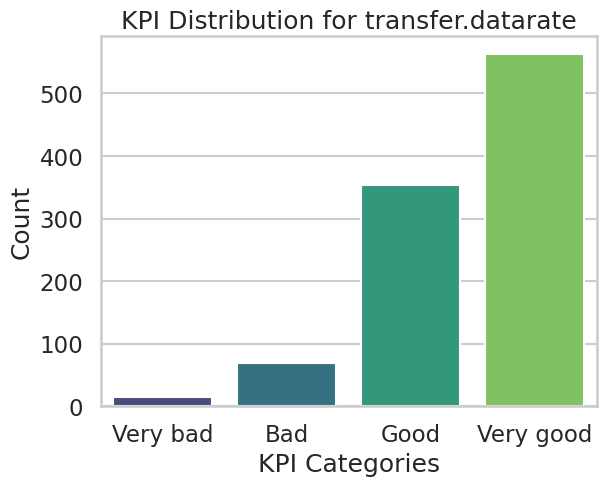

KPI category distribution after outlier removal:
Very bad: 15 samples
Bad: 69 samples
Good: 354 samples
Very good: 563 samples


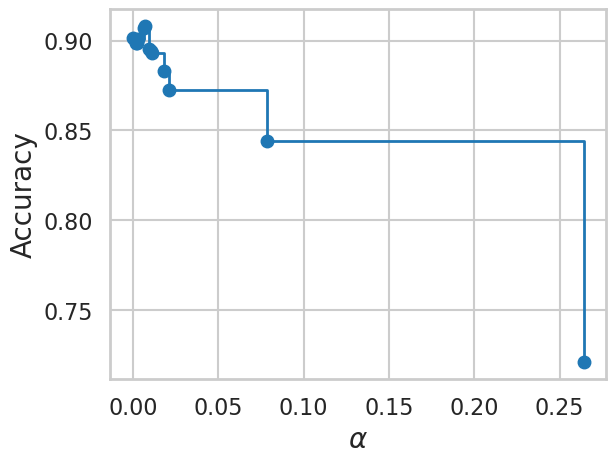

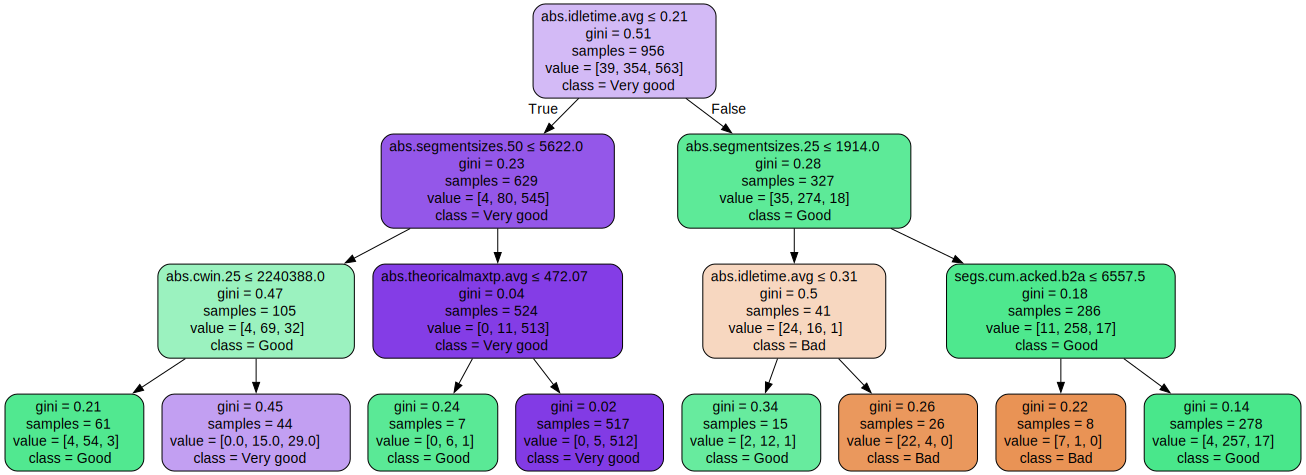

In [114]:
# -------------------------------------------------------------------
# KPI selection
# -------------------------------------------------------------------
target_kpi = 'transfer.datarate'
kpi_aux = data[target_kpi]
kpi_aux_log = np.log10(kpi_aux)

# -------------------------------------------------------------------
# Discretization of the target KPI for classification  
# -------------------------------------------------------------------
n_bins  = int(np.log2(len(kpi_aux_log))/2)
discretization_model = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans').fit(kpi_aux_log.values.reshape(-1, 1))
yd = discretization_model.transform(kpi_aux_log.values.reshape(-1, 1))[:,0]
val, count = np.unique(yd, return_counts=True)
labels = ['Very bad', 'Bad', 'Good', 'Very good']

plt.figure(dpi=100)
sns.barplot(x=val, y=count, palette='viridis')
plt.xticks(ticks=val, labels=labels)
plt.xlabel('KPI Categories')
plt.ylabel('Count')
plt.title(f'KPI Distribution for {target_kpi}')
plt.show()

# -------------------------------------------------------------------
# Rule-based anomaly detection to extract the normal data points for training the decision tree  
# -------------------------------------------------------------------
mask = detect_outliers_mad(kpi_aux_log)
mask = ~mask  # Invert mask to keep non-outliers
X_train = data.loc[mask, data.columns != target_kpi].values
y_train = data.loc[mask, target_kpi].values

# -------------------------------------------------------------------
# Normality model using a decision tree classifier  
# -------------------------------------------------------------------
vl, cnts = np.unique(yd, return_counts=True)
print("KPI category distribution after outlier removal:")
for category, count in zip(labels, cnts):
    print(f"{category}: {count} samples")
knowledge, scores, ccp_alphas, best_alpha = build_decision_tree(n_bins, 5, X_train, yd[mask], np.min(cnts))  
plot_pruning(ccp_alphas, scores)
bins = discretization_model.bin_edges_[0].tolist()
data1= pd.cut(x=kpi_aux_log[mask], bins = bins, labels=labels[0:val.shape[0]], include_lowest=True)
knowledge_label = DecisionTreeClassifier(max_depth=n_bins, min_samples_leaf=5, ccp_alpha=best_alpha)
knowledge_label.fit(X_train, data1)
y_pred = knowledge.predict(data.loc[:, data.columns != target_kpi].values)

dot_data = tree.export_graphviz(knowledge_label, 
                                feature_names = np.array(data.columns)[data.columns != target_kpi], 
                                class_names=knowledge_label.classes_, 
                                filled=True, 
                                rounded=True, 
                                out_file=None,
                                precision=2,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

### Inspecting discretized prediction errors

This cell compares the predicted KPI category with the observed discretized category.

The variable `Diff_Pred` stores the category difference:

- `0` means the prediction is correct,
- positive values indicate that the model overestimates the performance (the predicted label is better than the actual label) -> potential anomaly
- negative values indicate that the model underestimates the performance (the predicted label is worse that the actual label).

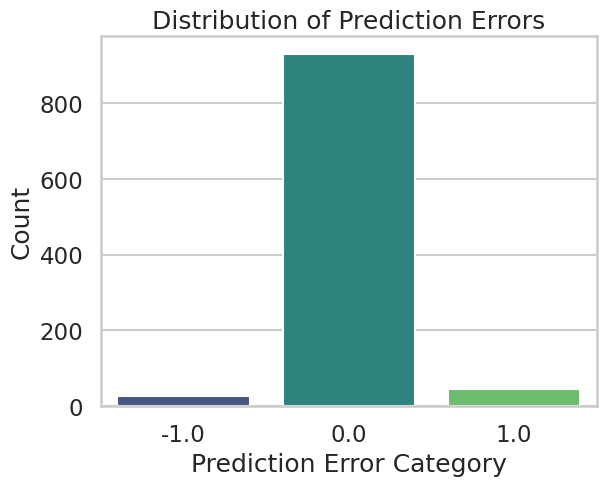

In [115]:
y_diff = y_pred - yd
data["Diff_Pred"] = y_diff
val, count = np.unique(y_diff, return_counts=True)

plt.figure(dpi=100)
sns.barplot(x=val, y=count, palette='viridis')
plt.xlabel('Prediction Error Category')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.show()

## 4. Explain the fitted model using feature importance, SHAP, and LIME.

### Global explanation through XGBoost feature importance

This cell extracts the feature-importance scores from the fitted XGBoost regressor and ranks the explanatory variables by their contribution to the model.

### What to look for

- Features with high importance contribute strongly to the regression model.
- They are not necessarily causal, but they indicate which variables the model relies on most to explain the KPI.

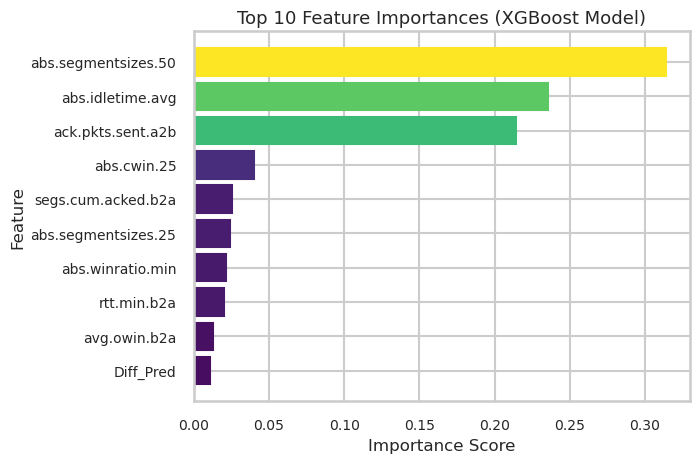


Top 10 Most Important Features:
            Feature  Importance
abs.segmentsizes.50    0.314021
   abs.idletime.avg    0.235209
  ack.pkts.sent.a2b    0.214172
        abs.cwin.25    0.039705
 segs.cum.acked.b2a    0.025318
abs.segmentsizes.25    0.024345
   abs.winratio.min    0.021219
        rtt.min.b2a    0.020397
       avg.owin.b2a    0.012596
          Diff_Pred    0.010885


In [116]:
RANDOM_STATE = 42
mask = detect_outliers_mad(kpi_aux_log)
mask = ~mask  # Invert mask to keep non-outliers

Xcols = data.columns[data.columns != target_kpi]
X_train = data.loc[mask, data.columns != target_kpi].values
y_train = data.loc[mask, target_kpi].values

# # Define parameter distributions for random search
# param_dist = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [3, 5, 7, 9, 11],
#     'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
#     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'gamma': [0, 0.1, 0.5, 1, 5],
#     'min_child_weight': [1, 3, 5, 7],
#     'reg_alpha': [0, 0.1, 0.5, 1],
#     'reg_lambda': [0, 0.1, 0.5, 1]
# }

# # Create base XGBoost regressor
# xgb_model = XGBRegressor(random_state=RANDOM_STATE, verbosity=0)

# # Perform random search with cross-validation
# random_search = RandomizedSearchCV(
#     estimator=xgb_model,
#     param_distributions=param_dist,
#     n_iter=50,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     verbose=1
# )

# # Fit the model
# random_search.fit(X_train, y_train)

# # Display best parameters and best score
# print(f"Best Parameters: {random_search.best_params_}")
# # Train final model with best parameters
# best_model = random_search.best_estimator_

best_model = XGBRegressor().fit(X_train, y_train)
y_pred = best_model.predict(X_train)

# Extract feature importances
feature_names = np.array(data.columns[data.columns != target_kpi])
importances = best_model.feature_importances_

# Create a DataFrame for better visualization and keep only the top 10 features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

# Plot the top 10 feature importances
fig, ax = plt.subplots()
bar_positions = np.arange(len(importance_df))
bars = ax.barh(bar_positions, importance_df['Importance'], edgecolor='black')
ax.set_yticks(bar_positions)
ax.set_yticklabels(importance_df['Feature'])
# Color bars by importance
colors = plt.cm.viridis(importance_df['Importance'] / importance_df['Importance'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 10 Feature Importances (XGBoost Model)', fontsize=13)
ax.tick_params(axis="both", labelsize=10)
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print(importance_df.to_string(index=False))

### Comparing feature importance across ensemble regressors

This section trains two additional tree-based regression models—**Gradient Boosting Regressor (GBR)** and **AdaBoost Regressor**—and compares their feature-importance rankings with the previously fitted **XGBoost** model.

#### Methodology and workflow

1. **Fit models**: Train GBR and AdaBoost regressors on the same clean training data used for XGBoost.
2. **Extract importance scores**: Retrieve feature-importance values from each of the three models independently.
3. **Rank features**: Identify the **top 10 most important features** within each model's ranking.
4. **Visualize side-by-side**: Create three horizontal bar plots for direct visual comparison of feature rankings.
5. **Compute cross-model consensus**: Calculate the **average feature rank** across all three models to identify consistently influential variables.

#### How to interpret the outputs

**Visual comparison (bar plots):**
- Each subplot displays the top 10 features for one regressor, ranked from highest to lowest importance.
- Longer bars indicate stronger model reliance on that feature.
- Features appearing in multiple top-10 lists (across the three subplots) suggest high cross-model stability.
- Features that are prominent in one subplot but absent from others may be model artifacts or interactions specific to that ensemble strategy.

**Cross-model ranking summary:**
- The printed summary reports the **average rank** of each feature across XGBoost, GBR, and AdaBoost.
- Lower average rank values (closer to 1) indicate consistently strong importance.
- Rank ties or near-ties indicate features that are similarly influential, though their exact importance scores may vary.
- Features with high variance across ranks (e.g., rank 3 in one model, rank 50 in another) are unreliable predictors and should be treated with caution in interpretation.

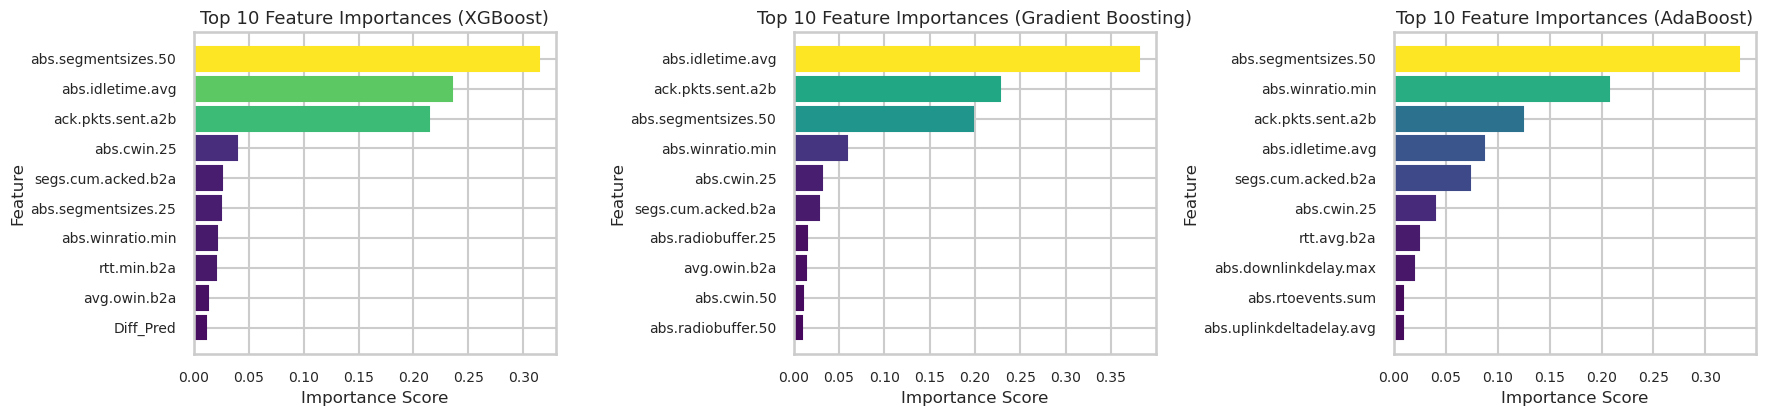


Top 10 Most Important Features (Averaged Rank):
abs.segmentsizes.50: Avg Rank 1.67 (XGB: 1, GBR: 3, Ada: 1)
abs.idletime.avg: Avg Rank 2.33 (XGB: 2, GBR: 1, Ada: 4)
ack.pkts.sent.a2b: Avg Rank 2.67 (XGB: 3, GBR: 2, Ada: 3)
abs.winratio.min: Avg Rank 4.33 (XGB: 7, GBR: 4, Ada: 2)
abs.cwin.25: Avg Rank 5.00 (XGB: 4, GBR: 5, Ada: 6)
segs.cum.acked.b2a: Avg Rank 5.33 (XGB: 5, GBR: 6, Ada: 5)
avg.owin.b2a: Avg Rank 9.67 (XGB: 9, GBR: 8, Ada: 12)
rtt.avg.b2a: Avg Rank 11.00 (XGB: 13, GBR: 13, Ada: 7)
abs.segmentsizes.25: Avg Rank 12.33 (XGB: 6, GBR: 14, Ada: 17)
abs.radiobuffer.25: Avg Rank 14.00 (XGB: 15, GBR: 7, Ada: 20)


In [117]:
gbr_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_train)

ada_model = AdaBoostRegressor(random_state=RANDOM_STATE)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_train)

# Extract feature importances
feature_names = np.array(data.columns[data.columns != target_kpi])

importances_xgb = best_model.feature_importances_
importances_gbr = gbr_model.feature_importances_
importances_ada = ada_model.feature_importances_

# Create DataFrames for top 10 features for each model
importance_df_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_xgb
}).sort_values('Importance', ascending=False).head(10)

importance_df_gbr = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_gbr
}).sort_values('Importance', ascending=False).head(10)

importance_df_ada = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_ada
}).sort_values('Importance', ascending=False).head(10)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

models = [
    ('XGBoost', importance_df_xgb),
    ('Gradient Boosting', importance_df_gbr),
    ('AdaBoost', importance_df_ada)
]

for ax, (model_name, df) in zip(axes, models):
    bar_positions = np.arange(len(df))
    bars = ax.barh(bar_positions, df['Importance'], edgecolor='black')
    ax.set_yticks(bar_positions)
    ax.set_yticklabels(df['Feature'])
    
    # Color bars by importance
    colors = plt.cm.viridis(df['Importance'] / df['Importance'].max())
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    ax.invert_yaxis()
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title(f'Top 10 Feature Importances ({model_name})', fontsize=13)
    ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

# Compute average rank of features across models
from scipy.stats import rankdata

# Get ranks for each model (lower rank = more important)
ranks_xgb = rankdata(-importances_xgb)  # rank 1 for highest importance
ranks_gbr = rankdata(-importances_gbr)
ranks_ada = rankdata(-importances_ada)

# Create a DataFrame with ranks
rank_df = pd.DataFrame({
    'Feature': feature_names,
    'Rank_XGB': ranks_xgb,
    'Rank_GBR': ranks_gbr,
    'Rank_Ada': ranks_ada
})

# Compute average rank
rank_df['Avg_Rank'] = rank_df[['Rank_XGB', 'Rank_GBR', 'Rank_Ada']].mean(axis=1)

# Sort by average rank ascending and get top 10
top_10_avg_rank = rank_df.sort_values('Avg_Rank').head(10)

# Print the top 10 features by average rank
print("\nTop 10 Most Important Features (Averaged Rank):")
for idx, row in top_10_avg_rank.iterrows():
    print(f"{row['Feature']}: Avg Rank {row['Avg_Rank']:.2f} (XGB: {row['Rank_XGB']:.0f}, GBR: {row['Rank_GBR']:.0f}, Ada: {row['Rank_Ada']:.0f})")

### Interpreting the Regression Model with PDP and ICE plots

This section uses **Partial Dependence Plots (PDP)** and **Individual Conditional Expectation (ICE)** plots to interpret how the fitted **Gradient Boosting Regressor (GBR)** responds to changes in individual features. 

#### Features under investigation

We examine two features selected based on their high importance rankings:

- `abs.segmentsizes.50`: a percentile-based metric of segment sizes
- `abs.idletime.avg`: average idle time across the network session

#### Workflow overview

1. **Prepare data**: Convert the training matrix into a pandas DataFrame to enable feature-by-name references.
2. **Generate PDP**: Create a Partial Dependence Plot for each feature, showing the average marginal effect.
3. **Generate ICE**: Create Individual Conditional Expectation plots for the same features, revealing sample-level heterogeneity.

#### Understanding PDP vs. ICE

- **Partial Dependence Plot (PDP)**: Shows the **average marginal effect** of a feature on predictions. The model is asked, "On average, what happens to the KPI when this feature changes, holding other variables at their observed distribution?" This provides a global, smoothed perspective.

- **Individual Conditional Expectation (ICE)**: Shows the same relationship **for each individual sample**. Instead of averaging, one curve is drawn per sample. This reveals whether the feature effect is **homogeneous** (consistent across samples) or **heterogeneous** (varies by context).

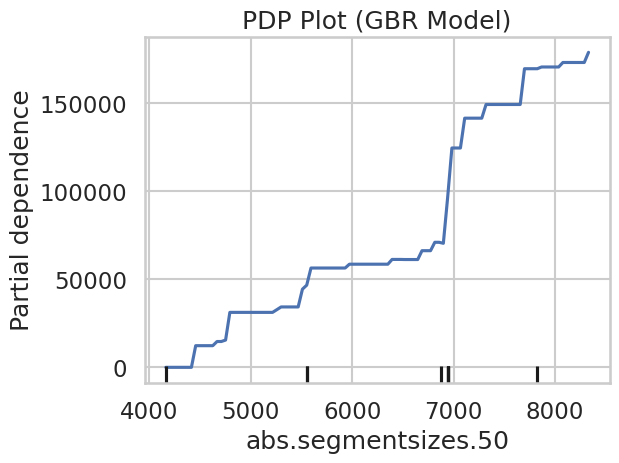

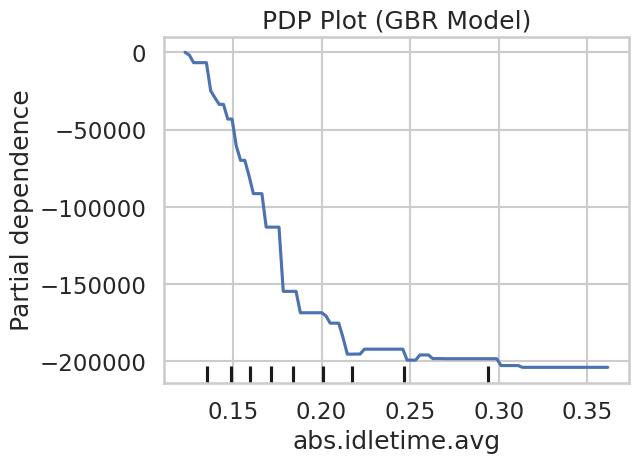

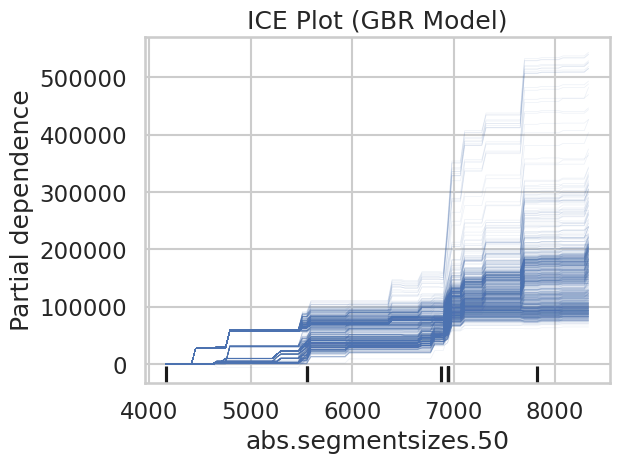

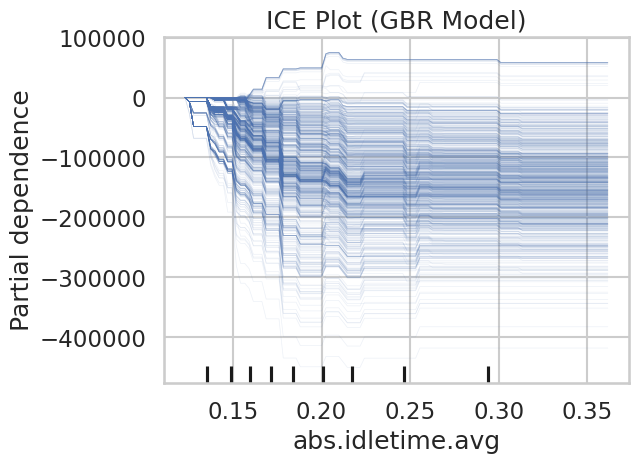

In [118]:
if GROUP_ID == 1:
    top_features = ['abs.segmentsizes.50', 'abs.idletime.avg']
elif GROUP_ID == 2:
    top_features = ['abs.theoricalmaxtp.avg', 'triple.dupacks.b2a']

# Create DataFrame for X_train
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Plot PDP for each top feature
for feature in top_features:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    PartialDependenceDisplay.from_estimator(gbr_model, X_train_df, [feature], kind='average', centered=True, ax=ax)
    ax.set_title(f'PDP Plot (GBR Model)')
    plt.show()

# Plot ICE for each top feature
for feature in top_features:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    PartialDependenceDisplay.from_estimator(gbr_model, X_train_df, [feature], kind='individual', centered=True, ax=ax, line_kw={'alpha': 0.1})
    ax.set_title(f'ICE Plot (GBR Model)')
    plt.show()

### Global and local explanation with SHAP

This cell uses **SHAP (SHapley Additive exPlanations)** to decompose the XGBoost predictions into feature contributions.

Two summary plots are produced:

- a **bar plot** showing the average absolute impact of each feature,
- a **dot plot** showing both magnitude and direction of the SHAP values across samples.

### Why it matters

SHAP links a predictive model with an additive explanation framework.  
It helps answer two complementary questions:

- which variables are important overall?
- for each variable, does it typically increase or decrease the predicted KPI?

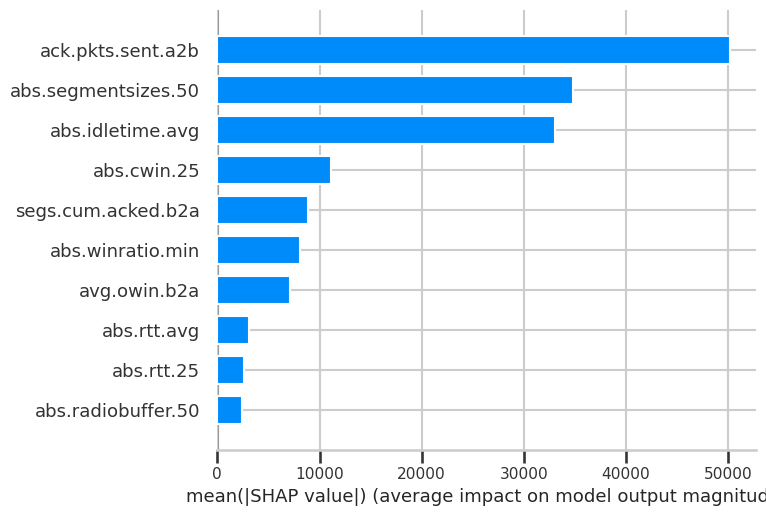

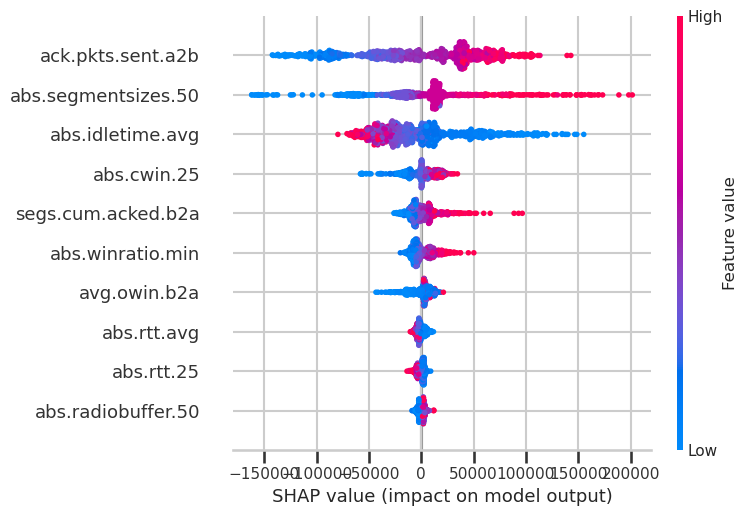

In [119]:
import shap

explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, features=X_train, feature_names=feature_names, plot_type="bar", max_display=10)
shap.summary_plot(shap_values, features=X_train, feature_names=feature_names, plot_type="dot", max_display=10)


### Analyzing correlations among top SHAP features

This cell examines the relationships between the **top 10 most important features** identified by SHAP (Shapley Additive exPlanations). By computing and visualizing Spearman correlations among these features, we can uncover potential multicollinearity issues that may affect model interpretation and stability.

#### Workflow overview

1. **Compute SHAP-based importance**: Calculate the mean absolute SHAP values across all samples to rank features by their overall impact on predictions.
2. **Select top features**: Extract the top 10 features with the highest mean absolute SHAP values.
3. **Compute correlations**: Calculate Spearman rank correlations among these top features to assess pairwise relationships.
4. **Visualize heatmap**: Generate a correlation heatmap with annotations showing the strength and direction of correlations.
5. **Display rankings**: Print the top 10 features along with their mean absolute SHAP values for reference.

#### Why this matters: Understanding feature interactions

SHAP provides additive feature contributions, but it doesn't directly reveal how features interact or correlate. High correlations among important features can indicate:

- **Redundant information**: Multiple features capturing similar aspects of the data, potentially leading to unstable importance rankings.
- **Interaction effects**: Features that are correlated may have complex joint effects that SHAP's additive framework might not fully capture.
- **Engineering insights**: Correlated features often represent related network mechanisms (e.g., buffer sizes and congestion metrics), helping engineers understand the underlying system dynamics.

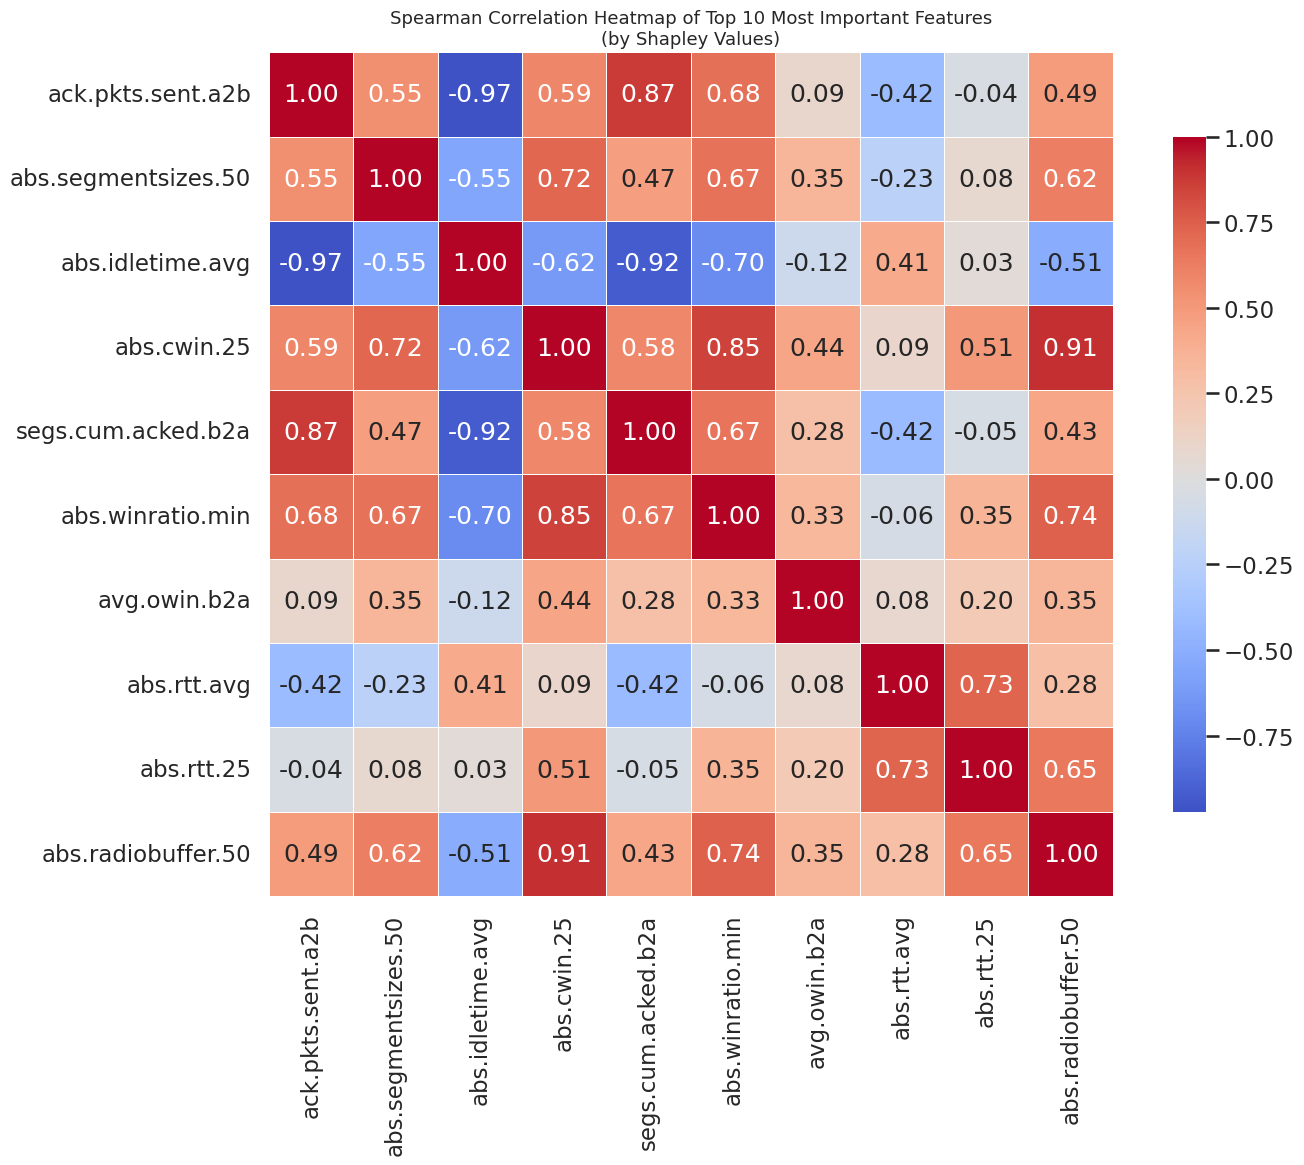


Top 10 Most Important Features (by Shapley Values):
            Feature  Mean_Abs_SHAP
  ack.pkts.sent.a2b   50211.605167
abs.segmentsizes.50   34828.402493
   abs.idletime.avg   33087.684791
        abs.cwin.25   11122.049534
 segs.cum.acked.b2a    8874.563372
   abs.winratio.min    8090.916337
       avg.owin.b2a    7083.172703
        abs.rtt.avg    3138.039220
         abs.rtt.25    2588.738393
 abs.radiobuffer.50    2366.937756


In [120]:
# Compute mean absolute SHAP values to identify top 10 features
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False).head(10)

top_10_shap_features = shap_importance_df['Feature'].tolist()

# Create DataFrame with only top 10 features
X_train_top10 = pd.DataFrame(X_train, columns=feature_names)[top_10_shap_features]

# Compute Spearman correlation
spearman_corr = X_train_top10.corr(method='spearman')

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Spearman Correlation Heatmap of Top 10 Most Important Features\n(by Shapley Values)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features (by Shapley Values):")
print(shap_importance_df.to_string(index=False))

### Exploring feature interactions with SHAP dependence plots

This cell generates **SHAP dependence plots** to visualize how feature interactions influence the model's predictions. Unlike simple feature importance, these plots reveal the **context-dependent effects** of variables, showing how the impact of one feature changes based on the values of another interacting feature.

#### What are SHAP dependence plots?

SHAP dependence plots display:
- **X-axis**: Values of the main feature being analyzed
- **Y-axis**: SHAP values (feature contributions) for that feature across all samples
- **Color coding**: Values of an interacting feature that modulates the main feature's effect
- **Scatter points**: Each point represents one sample's SHAP contribution

The plots help answer: "How does the effect of feature A change depending on the value of feature B?"

#### Features analyzed

We examine two pairs of interacting features:

1. **Main: `ack.pkts.sent.a2b`** (acknowledgment packets sent from client to server)  
   **Interaction: `segs.cum.acked.b2a`** (cumulative acknowledged segments from server to client)

2. **Main: `abs.cwin.25`** (25th percentile of congestion window sizes)  
   **Interaction: `abs.radiobuffer.50`** (50th percentile of radio buffer occupancy)

#### Workflow

1. **Select feature pairs**: Choose main features and their suspected interaction partners based on domain knowledge and correlation analysis.
2. **Generate plots**: Create one dependence plot per pair using SHAP's built-in visualization.
3. **Interpret patterns**: Analyze how the colored interaction feature modulates the SHAP values of the main feature.

#### Why this matters: Beyond additive explanations

SHAP's additive framework assumes features contribute independently, but real-world systems have interactions. Dependence plots reveal:

- **Non-linear interactions**: How feature effects change at different levels of the interacting variable
- **Threshold effects**: Points where the relationship between features changes dramatically
- **Context-dependent importance**: Features that matter only under specific conditions
- **Engineering insights**: Understanding coupled network mechanisms (e.g., how acknowledgment patterns interact with congestion control)

#### How to interpret the plots

**General patterns:**
- **Vertical spread**: At any x-value, the vertical scatter shows how much the feature's effect varies by context
- **Color gradients**: Systematic color changes across the plot indicate strong interactions
- **Clusters or bands**: Groups of points with similar colors suggest interaction thresholds
- **Outliers**: Points far from the main cloud may represent unusual interaction patterns

**For the acknowledgment pair:**
- Look for how cumulative acknowledgments modulate the impact of sent acknowledgments
- High interaction effects might indicate feedback loops in TCP congestion control

**For the congestion pair:**
- Observe how radio buffer levels influence congestion window effects
- Strong interactions could reveal radio resource constraints affecting transport layer behavior

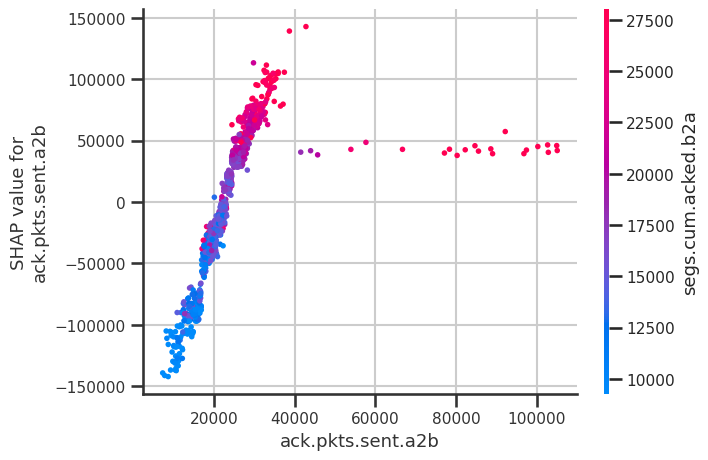

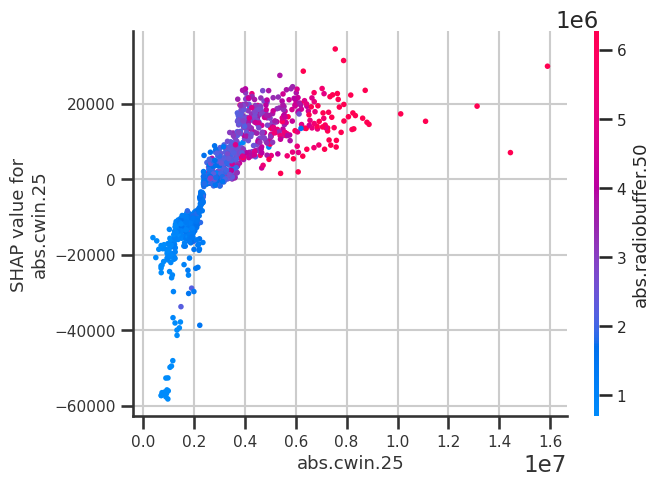

In [121]:
# Create figure with 2 subplots
if GROUP_ID == 1:
    fig= plt.figure(figsize=(7, 5))
    shap.dependence_plot('ack.pkts.sent.a2b', shap_values.values, X_train, interaction_index='segs.cum.acked.b2a',
                         feature_names=feature_names.tolist(), ax=plt.gca())
    plt.show()
    fig= plt.figure(figsize=(7, 5))
    shap.dependence_plot('abs.cwin.25', shap_values.values, X_train, interaction_index='abs.radiobuffer.50',
                         feature_names=feature_names.tolist(), ax=plt.gca())
    plt.show()
elif GROUP_ID == 2:
    fig= plt.figure(figsize=(7, 5))
    shap.dependence_plot('total.packets.a2b', shap_values.values, X_train, interaction_index='rtt.samples.b2a',
                         feature_names=feature_names.tolist(), ax=plt.gca())
    plt.show()
    fig= plt.figure(figsize=(7, 5))
    shap.dependence_plot('triple.dupacks.b2a', shap_values.values, X_train, interaction_index='duplicate.acks.b2a',
                         feature_names=feature_names.tolist(), ax=plt.gca())
    plt.show()

### Local explanation of a candidate anomaly with LIME

This cell uses **LIME** to explain a single sample from the set previously excluded by the MAD rule.

The workflow is:

1. initialize a tabular LIME explainer on the training data,
2. select one candidate anomalous sample,
3. compare its actual and predicted KPI values,
4. display the local feature contributions that drove the prediction.

### Why it matters

Unlike global importance measures, LIME focuses on **one observation at a time**.  
This is particularly useful in engineering troubleshooting, where the goal is often to understand why a specific test point deviates from expected network behaviour.

Explaining sample 0:
Actual throughput: 36488.1100
Predicted throughput: 183924.9219
Prediction error: 147436.8119


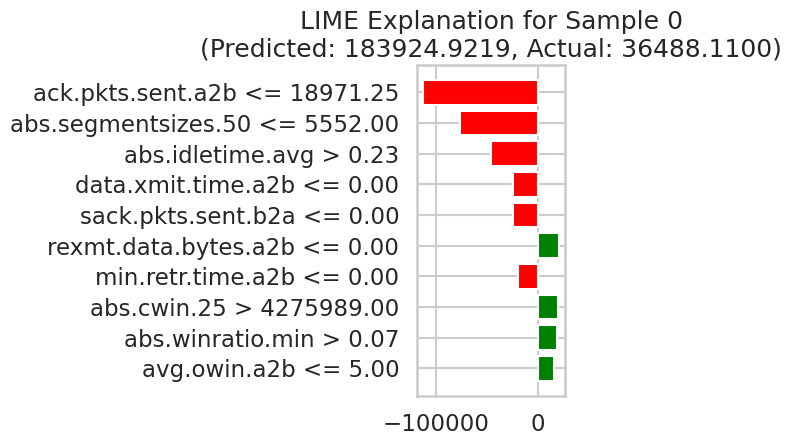


Feature contributions:
ack.pkts.sent.a2b <= 18971.25: -112739.2558
abs.segmentsizes.50 <= 5552.00: -77000.2707
abs.idletime.avg > 0.23: -46790.1996
data.xmit.time.a2b <= 0.00: -25199.9531
sack.pkts.sent.b2a <= 0.00: -25026.9289
rexmt.data.bytes.a2b <= 0.00: 20137.3135
min.retr.time.a2b <= 0.00: -19422.6802
abs.cwin.25 > 4275989.00: 19314.4414
abs.winratio.min > 0.07: 18511.8015
avg.owin.a2b <= 5.00: 15150.0795


In [122]:
from lime.lime_tabular import LimeTabularExplainer

X_test = data.loc[~mask, data.columns != target_kpi].values
y_test = data.loc[~mask, target_kpi].values
y_test_pred = best_model.predict(X_test)

# Create LIME explainer for regression
explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=Xcols.to_list(),
    mode='regression',
    random_state=RANDOM_STATE
)

# Choose a sample to explain (let's use the first anomalous sample)
sample_idx = 0  # Index of the sample to explain
sample_to_explain = X_test[sample_idx].reshape(1, -1)
actual_value = y_test[sample_idx]
predicted_value = y_test_pred[sample_idx]

print(f"Explaining sample {sample_idx}:")
print(f"Actual throughput: {actual_value:.4f}")
print(f"Predicted throughput: {predicted_value:.4f}")
print(f"Prediction error: {abs(actual_value - predicted_value):.4f}")

# Generate explanation
exp = explainer.explain_instance(
    data_row=sample_to_explain[0],
    predict_fn=best_model.predict,
    num_features=10  # Show top 10 features
)

# Plot the explanation
fig = exp.as_pyplot_figure()
plt.title(f'LIME Explanation for Sample {sample_idx}\n(Predicted: {predicted_value:.4f}, Actual: {actual_value:.4f})')
plt.tight_layout()
plt.show()

# Print the explanation details
print("\nFeature contributions:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")